[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ciri/iese-dsfb/blob/main/notebooks/210-Amazon-MiM.ipynb)

# Tabular: Amazon

Note: a solved version of this notebook is available [here](https://github.com/ciri/iese-dsfb/blob/main/notebooks/210-Amazon-MiM-solved.ipynb).


## Business Context

You are a **category manager** at an Indian fashion brand selling on Amazon India. It is July 2022, end of Q1. Your data covers April–June 2022 (~120,000 orders).

You have two decisions to make before next quarter:

> **1. Strategic:** Which product categories should you double down on next season — high-volume (Sets, Kurtas) or high-AOV (Western Dress)?
>
> **2. Operational:** Your cancellation rate is ~9%. What is the single most actionable fix?

As a secondary objective, you will have built the dashboard that answers both questions.

## Data Familiarization

You're working with real Amazon India Female fashion sales data from their Q2 2022 MRP which you can download [here](https://raw.githubusercontent.com/ciri/iese-dsfb/main/resources/tabular/AmazonSalesReport.csv). This dataset provides detailed insights into Amazon sales data, including SKU, product design, category, size, pricing, and fulfillment details. It is useful for analyzing sales performance and optimizing product profitability. Before doing any analysis, you need to understand what data you're looking at:

* What does each row represent?
* What kind of columns are available?
* Are there missing values?

First step: always **look at your data**. Use `.head()`/`.tail()` to see a sample, `.info()` to understand the structure, and `.describe()` for numeric summaries. We'll answer those questions using a few simple commands in pandas.

Typically datasets come with a *data dictionary* or a *data card* like this one:


| **Variable**       | **Description**                                               | **Type**    |
|--------------------|---------------------------------------------------------------|-------------|
| `category`         | Type of product (e.g., kurta, set, top)                       | String      |
| `size`             | Size of the product                                           | String      |
| `date`             | Date of the sale                                              | Date        |
| `status`           | Status of the order (e.g., Shipped, Cancelled)                | String      |
| `fulfilment`       | Who fulfilled the order (Amazon or Merchant)                  | String      |
| `style`            | Style identifier of the product                               | String      |
| `sku`              | Stock Keeping Unit, unique product ID                         | String      |
| `asin`             | Amazon Standard Identification Number                         | String      |
| `courier_status`   | Current status of the shipping courier                        | String      |
| `qty`              | Quantity of items ordered                                     | Integer     |
| `amount`           | Sale amount per item (in INR)                                          | Float       |
| `b2b`              | Whether the customer is a business                            | Boolean     |
| `currency`         | Currency used for the transaction (usually INR)               | String      |

Let's load it!


In [5]:
import pandas as pd

### Download it:
# df = pd.read_csv('https://raw.githubusercontent.com/ciri/iese-dsfb/main/resources/tabular/AmazonSalesReport.csv')

### Use local files
df = pd.read_csv('../resources/tabular/AmazonSalesReport.csv')

/tmp/ipykernel_14737/412006718.py:7: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../resources/tabular/AmazonSalesReport.csv')


You may be getting a warning. When pandas loads a CSV, it tries to infer the data type of each column (int, float, object, etc.). If a column has both numbers and text, pandas gets confused. Column 23 (24th column, likely 'fulfilled-by') has mixed types - probably some strings like "Easy Ship" and some missing values (NaN) or unexpected values like False.

In [6]:
df.describe()
df.head(3)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,base-SKU,SKU,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389,SET389-KR-NP-S,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781,JNE3781-KR-XXXL,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371,JNE3371-KR-XL,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN


## Pandas Quick Reference

Before diving into the cleaning and analysis, here are the three operations you'll use most — demonstrated on the data you just loaded.

| Operation | What it does |
|---|---|
| `df[mask]` | Filter rows using a condition |
| `df.merge(other, on=col)` | Join two tables on a shared column |

### Filtering rows

Rows are filtered by *Boolean masks* — an array of True/False values computed from a condition. You wrap the dataframe in square brackets with the mask:

In [7]:
f_shipped = df['Status'] == 'Shipped'
f_amazon  = df['Fulfilment'] == 'Amazon'

df[f_shipped & f_amazon][['Status', 'Fulfilment', 'Category', 'Amount']].head(5)

,Status,Fulfilment,Category,Amount
2,Shipped,Amazon,kurta,329.0
4,Shipped,Amazon,Top,574.0
5,Shipped,Amazon,Set,824.0
6,Shipped,Amazon,Set,653.0
9,Shipped,Amazon,kurta,363.0


### Merging datasets

In practice, data lives in **separate systems**: order details (status, shipping) sit in the order management system; product details (category, size) sit in the product catalog. To analyze them together you need a **merge** — the pandas equivalent of Excel's VLOOKUP or a SQL JOIN.

Here we load two separate files and join them on the shared key `SKU`. A `left` join keeps every row from the orders file — no information lost.

In [8]:
## Download it
# orders   = pd.read_csv('https://raw.githubusercontent.com/ciri/iese-dsfb/main/resources/tabular/AmazonOrders.csv')
# products = pd.read_csv('https://raw.githubusercontent.com/ciri/iese-dsfb/main/resources/tabular/AmazonProducts.csv')

## Use local files
orders   = pd.read_csv('../resources/tabular/AmazonOrders.csv')
products = pd.read_csv('../resources/tabular/AmazonProducts.csv')

orders.head(2)
products.head(2)

,SKU,base-SKU,Style,Category,Size
0,SET389-KR-NP-S,SET389,SET389,Set,S
1,JNE3781-KR-XXXL,JNE3781,JNE3781,kurta,3XL


In [9]:
df_merged = orders.merge(products, on='SKU', how='left')
df_merged[['Order ID', 'Status', 'Fulfilment', 'Category', 'Amount']].head(5)

,Order ID,Status,Fulfilment,Category,Amount
0,405-8078784-5731545,Cancelled,Merchant,Set,647.62
1,171-9198151-1101146,Shipped - Delivered to Buyer,Merchant,kurta,406.00
2,404-0687676-7273146,Shipped,Amazon,kurta,329.00
3,403-9615377-8133951,Cancelled,Merchant,Western Dress,753.33
4,407-1069790-7240320,Shipped,Amazon,Top,574.00


### 🧹 Data Cleaning

Before we can trust or analyze this data, we need to clean it. That means:

* Standardize column names so they’re consistent
* Drop unnecessary columns (like Excel export leftovers)
* Handle missing values in a simple, safe way

**Drop irrelevant columns**

In [10]:
df.columns # at the end there's a weird one, likely someone added one comma too many or had a value in excel at the end of the row
           # we also don't need this index

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'base-SKU', 'SKU', 'Category', 'Size',
       'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [11]:
df = df.drop(columns=['Unnamed: 22', 'index'])

**Rename columns**

Let's clean up some column names, ideally in python no spaces. Let's make it all very consistent.

In [12]:
# Rename confusing column names for clarity
df = df.rename(columns={
    'Order ID': 'order_id',
    'Date': 'date',
    'Status': 'status',
    'Fulfilment': 'fulfilment',
    'Sales Channel ': 'sales_channel',
    'ship-service-level': 'ship_service_level',
    'Style': 'style',
    'Category': 'category',
    'Size': 'size',
    'Courier Status': 'courier_status',
    'Qty': 'quantity',
    'currency': 'currency',
    'Amount': 'amount',
    'ship-city': 'ship_city',
    'ship-state': 'ship_state',
    'ship-postal-code': 'ship_postal_code',
    'ship-country': 'ship_country',
    'promotion-ids': 'promotion_ids',
    'fulfilled-by': 'fulfilled_by',
})
df.head(3)

,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,base-SKU,SKU,category,...,quantity,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,B2B,fulfilled_by
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389,SET389-KR-NP-S,Set,...,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781,JNE3781-KR-XXXL,kurta,...,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371,JNE3371-KR-XL,kurta,...,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN


**Handle missing values**

Are there missing values?

In [13]:
df.isna().sum()

order_id                  0
date                      0
status                    0
fulfilment                0
sales_channel             0
ship_service_level        0
style                     0
base-SKU                  0
SKU                       0
category                  0
size                      0
ASIN                      0
courier_status         6866
quantity                  0
currency               7786
amount                 7786
ship_city                33
ship_state               33
ship_postal_code         33
ship_country             33
promotion_ids         47530
B2B                       0
fulfilled_by          88023
dtype: int64

Note that `df.isna()` is a data frame of the same shape as `df`, whose terms have type `bool`. With `sum`, we get the number of `True` values per column.

Missing values are denoted by `NaN` in Pandas. When a Pandas object is built, both plain Python’s `None` and NumPy’s `nan` are taken as NaN. Since `np.nan` has type `float`, a numeric series containing NaN values
gets type float.

Three useful Pandas methods related to missing values, which can be applied to both series and data frames, are:
* `isna` returns a Boolean mask indicating which terms are missing.
* `fillna` is used for replacing `NaN`’s by a fixed value, set by the user.
* `dropna` returns the same data frame minus the rows that contain at least one missing value. If a list of columns is specified, the missing values are searched only for those columns.

For our case, let’s apply the following business rules:

- If *amount* or *currency* is missing, drop the row (we can't use it for financial analysis).
- If *courier status* is missing, fill it with `"Unknown"`.

The rest we leave as is.

In [14]:
df = df.dropna(subset=['amount', 'currency']).copy()
df['courier_status'] = df['courier_status'].fillna('Unknown')

**Remove Duplicates**

There are two useful Pandas functions for managing duplicates:

* `drop_duplicates` drops the duplicated entries (in a series) or the duplicated rows (in a data frame).
* `duplicated` returns a Boolean series indicating which entries (for a series) or which rows (for a data
frame) are duplicated.

In [15]:
df.duplicated().sum()

3

In [16]:
print('Before dropping duplicates:', df.shape)
df = df.drop_duplicates()
print('After dropping duplicates:', df.shape)

Before dropping duplicates: (118728, 23)
After dropping duplicates: (118725, 23)


**Any other final conversion**

Since I am not too familiar (intuitively) with INR, I prefer to convert to Euro. We could use an API for this conversion, but for the purposes of today an approximate exchange rate suffices.

In [17]:
exchange_rate = 0.0118 # In 2022
df['amount_eu']   = (df['amount'] * exchange_rate).round(2)

It's not at all clear what the `quantity` and `amounts` mean here. Let's rename these columns for clarity to `'quantity'`, `'unit_price'`, and `'revenue'`.


In [21]:
df['unit_price']  = df['amount_eu']
df['revenue']     = df['quantity'] * df['amount_eu']

It's good practice to save the dataframe after preprocessing this allows you to continue with a clean dataset going forward. Make sure you specify a path that makes sense to you. When in doubt you can just use `'./Amazon-cleaned.csv'`

In [19]:
df.to_csv('../resources/tabular/Amazon-cleaned.csv', index=False)

## Exploratory Analysis

In [22]:
df = pd.read_csv('../resources/tabular/Amazon-cleaned.csv')
df.head(3)

,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,base-SKU,SKU,category,...,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,B2B,fulfilled_by,amount_eu
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,7.64
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,4.79
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,3.88


## Revenue Trend over Time

### Adding time

Pandas has powerful tools to help you work with dates - but dates start as plain text ("strings"), which can't be analyzed or sorted properly.

So first, we **convert the `date` column** into a proper **datetime object**. Once we do that, we unlock a *lot* of cool tricks. Here's the flow:


| Concept              | What it Does                                                              |
|----------------------|---------------------------------------------------------------------------|
| `pd.to_datetime()`   | Converts text into a proper date format                                   |
| `.dt`                | A special "datetime accessor" in pandas - lets you pull out month, day, etc. |
| `.dt.month_name()` | Extracts the **month name** (e.g., "April") from a full date              |

In [23]:
df['date'] = pd.to_datetime(df['date'])

/tmp/ipykernel_14737/3532345252.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


In [24]:
df['month'] = df.date.dt.month_name()

To report sales per month we need to do a `groupby()` (explained in class). This is what it looks like conceptually in our case:

<center>
<img src='https://raw.githubusercontent.com/ciri/iese-dsfb/main/images/pandas_groupby.png' width='100%'>
</center>


This method groups the rows according to one or more **grouping variables**. Here, you specify `groupby(by='room_type')`.

Next, you select the columns to be aggregated, which, here would be just `price`. Finally, you specify the **aggregation function**. Having only the mean, you can do it just by adding `mean()` or by specifying `.agg('mean')`. The method `round()` works as you would expect it to.

In [29]:
monthly_revenue = df.groupby('month')[['revenue']].sum()
monthly_revenue

,revenue
month,
April,328611.70
June,268579.04
May,298847.94


In [30]:
# Reorder months chronologically (groupby returns them alphabetically)
month_order = ['April', 'May', 'June']
monthly_revenue = monthly_revenue.loc[month_order]
monthly_revenue

,revenue
month,
April,328611.70
May,298847.94
June,268579.04


In [31]:
# Calculate average revenue over last 3 months
# and how much below/above average we are
avg_q2_revenue = monthly_revenue['revenue'].mean()
avg_q2_revenue

monthly_revenue['% below avg'] = round((1 - monthly_revenue['revenue'] / avg_q2_revenue) * 100, 1)
monthly_revenue

,revenue,% below avg
month,,
April,328611.70,-10.0
May,298847.94,-0.1
June,268579.04,10.1


Charts are often more persuasive than tables. We will not waste time teaching this as you can ask LLM's to provide this to you. You can "vibe"-chart your way to great visualizations, just make sure that your dataframe above is 100% correct!

/tmp/ipykernel_164594/1770982019.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(list(range(0, 41, 5)))


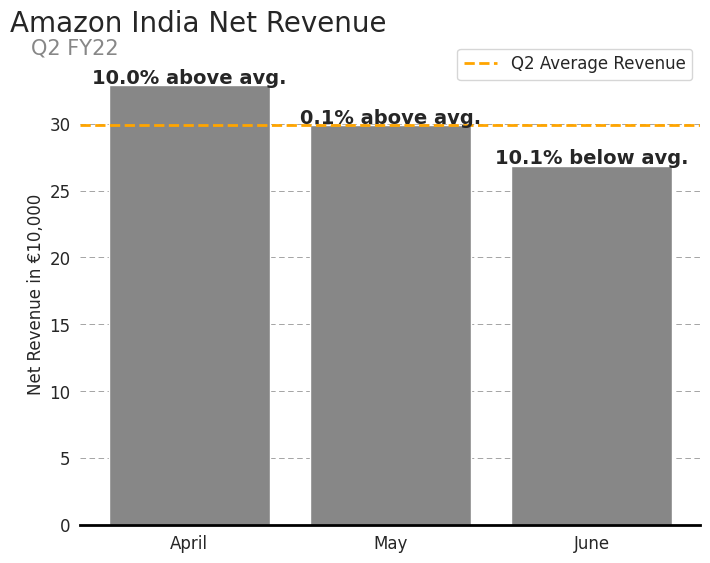

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(8, 6))

# Set-up data
monthly_revenue = df.groupby('month')[['revenue']].sum()

monthly_revenue = monthly_revenue.T[['April','May','June']].T
avg_q2_revenue = monthly_revenue['revenue'].mean()
monthly_revenue['% below avg'] = round((1 - monthly_revenue['revenue'] / avg_q2_revenue) * 100, 1)

# Plot bars
bars = ax.bar(monthly_revenue.index, monthly_revenue['revenue'], color='#878787')

# Add horizontal line for average
ax.axhline(avg_q2_revenue, linestyle='--', color='orange', linewidth=2, label='Q2 Average Revenue')

# Annotate each bar
for bar, pct in zip(bars, monthly_revenue['% below avg']):
    ax.annotate(f"{pct}% below avg." if pct > 0 else f"{abs(pct)}% above avg.",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height() - 7000),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=14, fontweight='bold')

# Titles and labels
ax.set_title("Amazon India Net Revenue", fontsize=20, x=0.19, y=1.05)
ax.text(-0.08, 1.02, "Q2 FY22", fontsize=15, color='#878787', transform=ax.transAxes)
ax.set_ylabel('Net Revenue in €10,000', fontsize=12, labelpad=3)
ax.set_xlabel(None)

# Ticks and grid
ax.set_yticklabels(list(range(0, 41, 5)))
ax.yaxis.grid(linestyle='--', color='gray', linewidth=0.5, dashes=(8, 5))
ax.xaxis.grid(False)
ax.tick_params(axis='both', labelsize=12)

# Spines
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['bottom'].set_color('black')

plt.legend(bbox_to_anchor=(1,1.05), fontsize=12, fancybox=True)
plt.show()

> Revenue declines steadily from April through June. One possible explanation is the Indian **festival calendar**: *Akshaya Tritiya (Apr 3)* and *Ram Navami (Apr 10)* are major auspicious shopping occasions, while *Eid al-Fitr (May 2–3; a significant fashion occasion for India's Muslim community (~15% of the population))* likely contributes to the early May uptick. June then quiets as peak summer heat reduces discretionary activity. 

**You try it:**

On which days is Amazon earning most of its revenue in India?

1. First create a column containing the day of the week. Hint: use `pd['<datefield>'].dt.day_name()` for this (day of the week) or alternatively `...dt.day` (day of month).
2. Then, use a groupby and an aggregation function to obtain the total revenue.
3. BONUS: plot the result using `df.plot.bar()` or `df.plot()`

You may want to produce something like this:

<center>
<img src='https://raw.githubusercontent.com/ciri/iese-dsfb/main/resources/amazon/sketch1.jpg' width='50%'>
</center>

## Product Portfolio Analysis

### Analysis: revenue across product categories?

*→ This feeds Decision 1: which category to invest in next season.*

Next question: **Which product categories generate the most revenue?**

Typical question to ask:
* Which category dominates revenue? Do we risk of over-dependence?
* Is there a drop-off after top 3 categories or any other long tail effect?
* Are high-volume categories also high-value? Might lead into later analysis (avg. order value).

We'll use `groupby()` again, but this time by `category`. It works just like with months, but this helps us understand which types of products are performing best.

### Analysis: Average Order Value by Category

Revenue alone doesn’t tell the full story. Some categories might generate fewer sales but have *higher order values*.

Let’s calculate **average revenue per order** (AOV) for each product category.

**You try it**

Tabulate and then plot the average order value per category.

You may want to produce something like this:

<center>
<img src='https://raw.githubusercontent.com/ciri/iese-dsfb/main/resources/amazon/sketch2.jpg' width='50%'>
</center>

In [33]:
# Calculate the Average Order Value (AOV) per category
# AOV = mean revenue per order, grouped by category
# 
# Hint: use a groupby + mean combination.
#
# Store the result in: category_aov
# category_aov = ...

### Analysis: Product Portfolio Matrix

We can think of each product category as a portfolio element. High revenue = popularity. High AOV = a proxy profitability per sale. The latter is only true here because we're dealing with approximately similar margins. Plotting these gives us a clear 2x2 matrix for strategy.

<center>
<img src='https://raw.githubusercontent.com/ciri/iese-dsfb/main/resources/amazon/sketch3.jpg' width='50%'>
</center>

This lens can offer some potential strategical actions to take for the product types:
* **Underperformers**: Consider retiring or repositioning
* **Volume Drivers**: Focus on logistics, bundling, efficiency
* **Niche Upside**: Test with promos or better visibility
* **Premium Performers**: Upsell, promote, ...

In [34]:
import matplotlib.pyplot as plt

# Calculate total revenue and AOV per category
category_metrics = df.groupby('category').agg(
    total_revenue   = ('revenue', 'sum'),
    avg_order_value = ('revenue', 'mean')
).reset_index()
category_metrics

,category,total_revenue,avg_order_value
0,Blouse,5204.38,6.065711
1,Bottom,1685.54,4.121125
2,Dupatta,10.80,3.600000
3,Ethnic Dress,8990.13,8.481255
4,Saree,1484.04,9.636623
5,Set,446968.24,9.720927
6,Top,61811.64,6.188590
7,Western Dress,126292.35,8.723655
8,kurta,243591.56,5.319058


**You try it**

Try to scatter plot the total revenue v.s. median order value. The command you'll use is `df.plot.scatter(x=...,y=...)`.

In [35]:
# Create a scatter plot with one point per category:
#   x-axis: total revenue for that category
#   y-axis: average order value (AOV) for that category
#
# Hint: first build a summary dataframe with both metrics
# category_metrics = df.groupby('category')['revenue'].agg(...)
# Then plot with category_metrics.plot.scatter(x=..., y=...)

In [36]:
# --- filler: ensures notebook runs ---
category_metrics = df.groupby('category')['revenue'].agg(
    total_revenue='sum',
    avg_order_value='mean'
).reset_index()

## Cancellations & Returns

Not all orders are good news. In e-commerce, cancellations and returns create serious operational and financial issues:
* Lost revenue: These orders don't convert into sales.
* Shipping and handling costs: Often non-refundable.
* Reverse logistics: Costly and time-consuming.
* Chargebacks: Especially if customers dispute transactions.
* Fraud & abuse: Repeated returns or B2C-to-B2B loopholes.
* Money laundering flags: In some cases, abnormal return behavior is a red flag.

Long story short: cancellations and returns hurt revenue.

Let's measure the size of the problem:

* How many orders were cancelled?
* How many were returned?
* What percentage of total orders does this represent?

So far, you've used `.groupby()` for totals and averages. This time let's introduce `.value_counts()` which is a quick way to count categories in one column, like a faster `.groupby('status').shape`.

*→ This feeds Decision 2: where to focus the operational fix.*

In [37]:
# Analyse order cancellations — find where the problem is
#
# Step 1: What % of all orders are cancelled?
#   Hint: use df['status'].value_counts() to see all statuses
#   Hint: (df['status'] == 'Cancelled').mean() gives you the rate
#
# Step 2: Does cancellation rate differ by fulfilment type?
#   Hint: df.groupby('fulfilment')['status'].apply(lambda x: (x == 'Cancelled').mean())
#   Store result in: cancel_by_fulfilment
#
# Step 3: Does cancellation rate differ by category?
#   Hint: same pattern, groupby 'category' instead
#   Store result in: cancel_by_category
#
# Step 4: Visualise — which split tells the more actionable story?
#   Hint: try a bar chart on each result

In [38]:
# See solution at end of notebook

## State Dashboard

The goal is often not just to analyze but rather to communicate insights clearly as we've been trying to do before. Sometimes a plot is enough, other times a dynamic dashboard is needed.

Dashboards allow other users (e.g., regional managers) to quickly:

* See how their region is doing
* Spot product trends
* Act on poor performance
* ..

We'll build a simple command-line dashboard first, and then make it interactive. We're working towards something like this that shows per-state statistics:

<center>
<img src='https://raw.githubusercontent.com/ciri/iese-dsfb/main/resources/amazon/sketch4.jpg' width='50%'>
</center>

Let's first look at the states:

*→ This gives us situational awareness: where is our business concentrated?*

In [39]:
df.ship_state.unique()

array(['MAHARASHTRA', 'KARNATAKA', 'PUDUCHERRY', 'TAMIL NADU',
       'UTTAR PRADESH', 'CHANDIGARH', 'TELANGANA', 'ANDHRA PRADESH',
       'RAJASTHAN', 'DELHI', 'HARYANA', 'ASSAM', 'JHARKHAND',
       'CHHATTISGARH', 'ODISHA', 'KERALA', 'MADHYA PRADESH',
       'WEST BENGAL', 'NAGALAND', 'GUJARAT', 'UTTARAKHAND', 'BIHAR',
       'JAMMU & KASHMIR', 'PUNJAB', 'HIMACHAL PRADESH',
       'ARUNACHAL PRADESH', 'MANIPUR', 'GOA', 'MEGHALAYA', 'TRIPURA',
       'LADAKH', 'DADRA AND NAGAR', 'SIKKIM', nan, 'ANDAMAN & NICOBAR',
       'RAJSHTHAN', 'NL', 'MIZORAM', 'NEW DELHI',
       'PUNJAB/MOHALI/ZIRAKPUR', 'RJ', 'ORISSA', 'LAKSHADWEEP', 'PB',
       'AR', 'PONDICHERRY', 'RAJSTHAN'], dtype=object)

Let's pick just one state to understand its sales profile. We'll start with Karnataka, one of the largest markets

In [46]:
# Filter data for Karnataka
karnataka = df[df['ship_state'] == 'KARNATAKA']

In [47]:
# Calculate the number of orders placed in this state
total_orders = len(karnataka)

# Calculate total revenue generated
total_revenue = karnataka['amount_eu'].sum()

# Average revenue per order — helps identify spending behavior
avg_order_value = karnataka['amount_eu'].mean()

# Find the most popular product category by quantity sold
top_category = (
    karnataka.groupby('category')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

# Print the summary stats
print(f"Total Orders: {total_orders}")
print(f"Total Revenue: €{total_revenue:,.2f}")
print(f"Average Order Value: €{avg_order_value:,.2f}")
print(f"Top Category: {top_category.index[0]} ({top_category.values[0]} units)")

Total Orders: 16050
Total Revenue: €123,519.42
Average Order Value: €7.70
Top Category: kurta (6085 units)


**You try it (at home)**: write a dashboard function `draw_state_dashboard(state)` that takes as input a `state` and prints the above statistics.

In [48]:
# Write a function: draw_state_dashboard(state)
# 
# Given a state name (e.g. 'KARNATAKA'), it should print/display:
#   1. Total number of orders for that state
#   2. Total revenue (sum of revenue column)
#   3. Average Order Value (mean of revenue)
#   4. Top category by revenue
#
# Hint: filter the dataframe first: state_df = df[df['ship_state'] == state]
# Then compute each KPI on state_df
#
# def draw_state_dashboard(state):
#     state_df = df[df['ship_state'] == state]
#     ...

**Dashboard**

In [49]:
# --- filler: ensures notebook runs ---
def draw_state_dashboard(state):
    state_df = df[df['ship_state'] == state]
    orders = len(state_df)
    revenue = state_df['revenue'].sum()
    aov = state_df['revenue'].mean()
    top_cat = state_df.groupby('category')['revenue'].sum().idxmax()
    print(f"State: {state}")
    print(f"  Orders:         {orders:,}")
    print(f"  Total Revenue:  €{revenue:,.0f}")
    print(f"  AOV:            €{aov:.2f}")
    print(f"  Top Category:   {top_cat}")

### BONUS: add some analysis from before to make it prettier

Note: in production you will want to use plotly dash, which functions similar to what we've seen above. Here are a [couple of examples](https://plotly.com/examples/), and one for [Amazon](https://challenge-amazon.onrender.com/puchase_overview).

In [50]:
# See solution at end of notebook

In [resources](https://github.com/ciri/iese-dsfb/tree/main/resources/amazon/dashboard) you'll find the full code to make an interactive dashboard based on the above functions using python.

Credits: original data source from [here](https://data.world/anilsharma87).

---
## Solutions

### Solution: Category Revenue Analysis

In [51]:
category_revenue = df.groupby('category')[['revenue']].sum()
category_revenue = category_revenue / category_revenue.sum() * 100

category_revenue = category_revenue.sort_values(ascending=False, by='revenue')
category_revenue

,revenue
category,
Set,49.876785
kurta,27.094108
Western Dress,14.280312
Top,6.807375
Ethnic Dress,1.006678
Blouse,0.583757
Bottom,0.191925
Saree,0.157895
Dupatta,0.001166


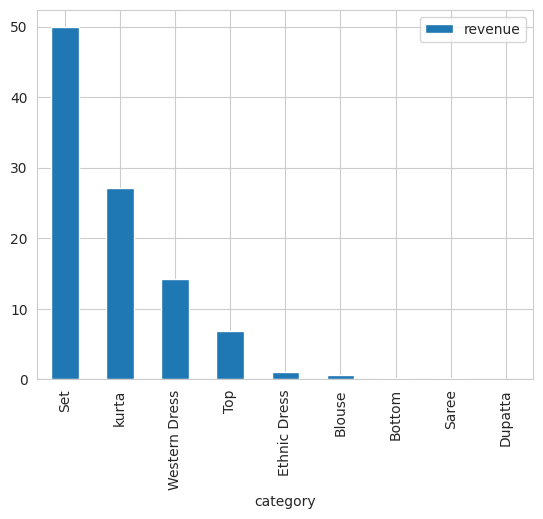

In [52]:
# Basic plot command
category_revenue.plot.bar();

# Bonus

### Revenue by Customer Type (B2B vs. Regular)

Amazon doesn't just sell to everyday consumers — it also serves **business buyers** through **Amazon Business**.

| **Customer Type** | **Examples**                                      | **What They Value**                                |
|--------------------|---------------------------------------------------|----------------------------------------------------|
| Regular (B2C)       | Individual shoppers buying for personal use      | Price, fast shipping, product variety              |
| Business (B2B)      | SMEs, schools, retailers buying in bulk          | Discounts, tax invoices, delivery reliability, APIs|

Business customers usually spend more per order — but place fewer orders.  
Regular customers are more frequent, but each transaction is smaller.

To understand these channels better, let us look at some stats:
1. Total revenue by customer type  
2. Average order value (AOV) by customer type  
3. Number of orders by customer type

In [53]:
# Step 1: Group by customer type and summarize metrics
customer_summary = df.groupby('B2B').agg(
    total_revenue   = ('amount_eu', 'sum'),
    avg_order_value = ('amount_eu', 'mean'),
    order_count     = ('order_id', 'count')
).reset_index()
customer_summary

,B2B,total_revenue,avg_order_value,order_count
0,False,919207.39,7.797691,117882
1,True,6976.65,8.275979,843


In [54]:
# Step 2: Convert True/False to readable labels
customer_summary['B2B'] = customer_summary['B2B'].replace({True: 'B2B', False: 'B2C'})
customer_summary

,B2B,total_revenue,avg_order_value,order_count
0,B2C,919207.39,7.797691,117882
1,B2B,6976.65,8.275979,843


**Observations**:

| **Metric**         | **What It Shows**                                                                                |
|--------------------|--------------------------------------------------------------------------------------------------|
| **Order Count** | Regular customers dominate volume — this is the bulk of the business                            |
| **AOV**         | Business customers spend **~8% more per order** (€7.71 vs €7.13) but much less than expected.                                  |
| **Total Revenue** | Business is currently a *tiny slice* of total revenue (~0.75%) — but with higher ticket size |

Potential actionable insight: one last attempt at invigorating and attracting better B2B through e.g. exclusive deals, bulk pricing, repeate order flows? If it doesn't work we may consider spinning off or integrating it into B2C.

### Interactive State Selector (ipywidgets)

The dashboard in `resources/amazon/dashboard/` is a production-quality version of this. The cell below shows the interactive widget version for use directly in Jupyter.

Wonderful, all that is needed at this point is to make it interactive with a dropdown. Note: this code assumes that you are using a notebook like google collab or jupyter lab. Notably it won't work in VS Code.

Note: You will need to install and enable widgets, it doesn't always work on every environment.

In [55]:
! pip install ipywidgets==8.0.2
! pip install jupyterlab_widgets==3.0.13

It's possible that you need to restart your kernel after doing this. If that's the case, do so now and run the cell after this:

In [56]:
import pandas as pd
#### Download cleaned data
# df = pd.read_csv("https://raw.githubusercontent.com/ciri/iese-dsfb/refs/heads/main/resources/tabular/Amazon-cleaned.csv")
#### Or use your local copy
# df = pd.read_csv("../resources/tabular/Amazon-cleaned.csv")

In [57]:
import ipywidgets as widgets
from IPython.display import display

output          = widgets.Output()
state_dropdown  = widgets.Dropdown(
    options=sorted(df['ship_state'].dropna().unique()),
    description='Select a State:',
    style={'description_width': 'initial'}
)

def on_state_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        output.clear_output(wait=True)
        with output:
            draw_state_dashboard(change['new'])

state_dropdown.observe(on_state_change)
display(state_dropdown, output);

Dropdown(description='Select a State:', options=('ANDAMAN & NICOBAR', 'ANDHRA PRADESH', 'AR', 'ARUNACHAL PRADE…

Output()